# Exercises

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.optimize import minimize
import sys


sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


print(sys.path)
sys.path.append('C:/Users/Beheerder/OneDrive/Documents/Radboud Universiteit/Master/Neuro Analysis/neural-data-master/Neuro_Analysis_def/2-single-cell-analysis-master/02-GLMs/code')


In [ ]:
#import supporting functions
from utilities import create_receptive_field
from utilities import generate_data_linear

## Exercise 1
---
Determine the effect of stimulus sequence duration on RF estimates. To do this, repeat the above steps for different durations (5 s, 10 s, 20 s, 40 s, 80 s, 160 s, 320 s, 640 s). Compute the Pearson correlation between true and estimated RFs for each duration to quantify the accuracy of the estimator. The Pearson correlation $\mathrm{cc}$ is defined as
$$
\mathrm{cc} = \frac{\mathbf{k}_\mathrm{true}^T \hat{\mathbf{k}}}{\lVert \mathbf{k}_\mathrm{true} \rVert \lVert \hat{\mathbf{k}} \rVert}
$$
where $\lVert \cdot \rVert$ is the L2-norm (vector length).
As the response generation process is stochastic, compute the average correlation across 10 realizations for the same duration and plot the average correlation as a function of duration. How is the recording duration related to the ability to recover the true RF?

To do this, we have to do the same but create a loop for the code, see below. Just as in the lecture notes, we generated a stimulus, simulated the spiking responses using the linear-nonlinear Poisson model, estimated the RF and computed the Pearson's correlation between the real and estimated RF. What we see in the plot is that the average Pearson's correlation increases when we increase the stimulus duration. This makes sense and also correspond to what was said in the lecture, as with longer recordings, the model has access to more data, which improves the signal-to-noise ratio when estimating the RF. This allows the model to estimate a better fit for the RF.



In [ ]:
#use generate linear data function but make sure it is adapted so that it doesn't return any negative outputs

def generate_data_linear(S, K, dt=0.1, offset=2.0, noise_variance=4, f_nonlin=lambda x: np.maximum(0, x)):
    """
    Generate spikes using a linear-nonlinear model with custom stimulus and RF.

    Parameters:
    -----------
    S : ndarray
        Stimulus (time x space) - 3D (time, width, height)
    K : ndarray
        Receptive field (2D)
    dt : float
        Bin width in seconds
    offset : float
        Additive offset to the linear response
    noise_variance : float
        Gaussian noise variance
    f_nonlin : function
        Nonlinearity (default = identity)

    Returns:
    --------
    spikes : ndarray
        Simulated spike counts
    X_flat : ndarray
        Flattened stimulus
    K : ndarray
        True receptive field
    rate : ndarray
        Firing rates before Poisson sampling
    """
    n_bins = S.shape[0]
    X_flat = S.reshape(n_bins, -1)
    k_flat = K.flatten()

    # Linear projection + offset
    lin_output = X_flat @ k_flat + offset

    # Apply nonlinearity
    rate = f_nonlin(lin_output)

    # Add noise
    rate += np.sqrt(noise_variance) * np.random.randn(*rate.shape)

    # Clip negative or invalid values to ensure valid Poisson λ
    rate = np.clip(rate, 0, None)

    # Poisson spike generation
    spikes = np.random.poisson(rate * dt)

    return spikes, X_flat, K, rate


In [47]:
durations = [5, 10, 20, 40, 80, 160, 320, 640]
dt = .1
vf_size = (15,15)
repeats = 10

# Create a fixed ground truth receptive field
K_true = create_receptive_field()

avg_correlations = []

In [ ]:
for duration in durations:
    n_bins = round(duration / dt)
    correlations = []

    for _ in range(repeats):
        # Generate Gaussian stimulus
        S = np.random.randn(n_bins, *vf_size)

        # Simulate spikes using the linear model
        spikes, X_flat, _, _ = generate_data_linear(S, K_true, dt)

        # Estimate the RF using least squares
        K_est_flat = np.linalg.pinv(X_flat) @ spikes
        K_est = K_est_flat.reshape(vf_size)

        # Compute Pearson correlation between true and estimated RFs
        cc = np.corrcoef(K_true.flatten(), K_est.flatten())[0, 1]
        correlations.append(cc)

    # Average over all repeats
    avg_correlations.append(np.mean(correlations))

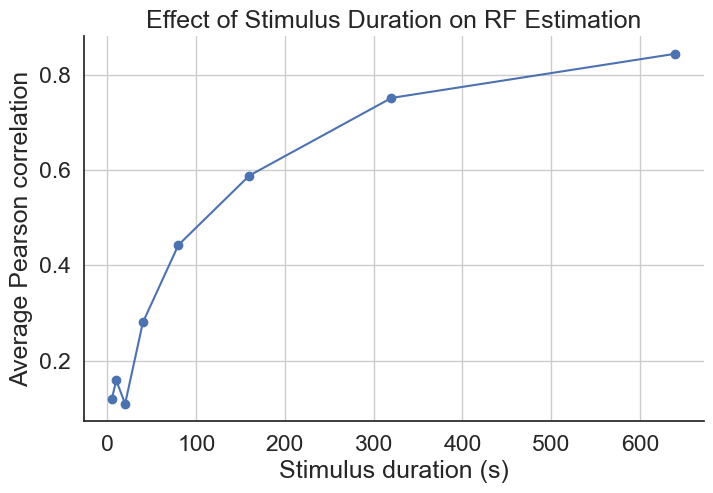

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(durations, avg_correlations, marker='o')
plt.xlabel('Stimulus duration (s)')
plt.ylabel('Average Pearson correlation')
plt.title('Effect of Stimulus Duration on RF Estimation')
plt.grid(True)
plt.show()

## Exercise 2
---

Determine the effect of response noise ($\sigma^2$) on RF estimates. Try different value for the noise variance in the simulations, e.g., 0, 2, 4, 6, 8, and 10 for a duration of 100 s. As in the previous excercise, repeatedly estimate RF parameters for each condition (10 times) but this time also plot the standard deviation of the correlations across the different runs for each condition.

In [55]:
duration = 100  # in seconds
dt = 0.1
vf_size = (15, 15)
repeats = 10
noise_levels = [0, 2, 4, 6, 8, 10]

# Create a true receptive field
K_true = create_receptive_field()
S = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])

# Linear model 
def generate_data_linear(S, K, dt=0.1, offset=2.0, noise_variance=4, f_nonlin=lambda x: np.maximum(0, x)):
    n_bins = S.shape[0]
    X_flat = S.reshape(n_bins, -1)
    k_flat = K.flatten()

    lin_output = X_flat @ k_flat + offset
    rate = f_nonlin(lin_output)
    rate += np.sqrt(noise_variance) * np.random.randn(*rate.shape)
    rate = np.clip(rate, 0, None)
    spikes = np.random.poisson(rate * dt)

    return spikes, X_flat, K, rate

# Store results
avg_correlations = []
std_correlations = []

n_bins = round(duration / dt)

for noise_var in noise_levels:
    correlations = []

    for _ in range(repeats):
        # Generate stimulus
        S = np.random.randn(n_bins, *vf_size)

        # Simulate spike responses with current noise variance
        spikes, X_flat, _, _ = generate_data_linear(S, K_true, dt, noise_variance=noise_var)

        # Estimate RF
        K_est_flat = np.linalg.pinv(X_flat) @ spikes
        K_est = K_est_flat.reshape(vf_size)

        # Pearson correlation
        cc = np.corrcoef(K_true.flatten(), K_est.flatten())[0, 1]
        correlations.append(cc)

    # Store mean and std
    avg_correlations.append(np.mean(correlations))
    std_correlations.append(np.std(correlations))

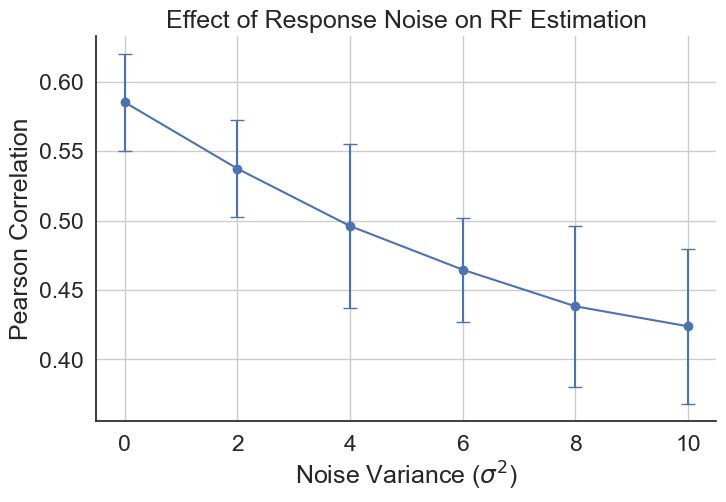

In [56]:
# Plotting
plt.figure(figsize=(8, 5))
plt.errorbar(noise_levels, avg_correlations, yerr=std_correlations, fmt='-o', capsize=5)
plt.xlabel('Noise Variance ($\sigma^2$)')
plt.ylabel('Pearson Correlation')
plt.title('Effect of Response Noise on RF Estimation')
plt.grid(True)
plt.show()


## Exercise 3
---
Look at the analytical derivation of the log-likelihood for the poisson GLM.
Which of the terms are required for maximizing the likelihood with respect to $\mathbf{k}$ and which terms can be ignored? **Note:** due to the independence of spikes in the different bins, the likelihood can be written as $P(R | S, \mathbf{k}) = \prod_t^T P(r_t | \mathbf{s}_t, \mathbf{k})$. The log turns the product into a sum which makes life much easier.  

When maximizing the log-likelihoood for the poisson GLM, you can ignore the terms that don't depend on k (the variable that has to be optimized). 

For a Linear-Nonlinear Poisson (LNP) model with an exponential nonlinearity  
$\lambda_t = \exp(\mathbf{k}^\top \mathbf{s}_t)$,  
the log-likelihood for a single observation is:

$$
\log P(r_t | \lambda_t) = r_t \log \lambda_t + r_t \log \Delta - \log r_t! - \lambda_t \Delta
$$

Summing over all time bins, the full log-likelihood becomes:

$$
\log P(R | \lambda) = \sum_t \left[ r_t \log \lambda_t + r_t \log \Delta - \log r_t! - \lambda_t \Delta \right]
$$

When optimizing with respect to $\mathbf{k}$, we can ignore constant terms  
$r_t \log \Delta$ and $\log r_t!$, leaving:

$$
\mathcal{L}(\mathbf{k}) = \sum_t \left[ r_t \mathbf{k}^\top \mathbf{s}_t - \Delta \exp(\mathbf{k}^\top \mathbf{s}_t) \right]
$$

The gradient of the log-likelihood with respect to $\mathbf{k}$ is:

$$
\frac{\partial \log P}{\partial \mathbf{k}} = \sum_t r_t \mathbf{s}_t - \Delta \sum_t \lambda_t \mathbf{s}_t
$$


## Exercise 4
---
Explore the effect of the data duration and the firing rate on the goodness of fit of the Poisson GLM.

A - Generate data with durations of 10,20,50,100 and 200 seconds. Fit the model on each dataset and plot the fitted parameters.
Use the pearson correlation as a proxy of the goodness of fit, and plot it as a function of the duration of the data.

B - Fix the duration to 100s, and change the average firing rate of the simulation. How does the fit perform for different firing rates? 

## Effect of duration

## Effect of firing rate